In [1]:
# Assignment - Part 4: Data Visualization & Machine Learning
# Theme: Student Performance Analysis & Prediction

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")


# ----------------------------
# Task 1 - Data Exploration with Pandas
# ----------------------------
def main():
    print("TASK 1 - DATA EXPLORATION WITH PANDAS")
print("-" * 60)

df = pd.read_csv("students.csv")
subject_cols = ['math', 'science', 'english', 'history', 'pe']
print("\nFirst 5 rows:")
print(df.head())    
print("\nShape of dataset:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

print("\nPass / Fail counts:")
print(df['passed'].value_counts())

passing_means = df[df['passed'] == 1][subject_cols].mean()
failing_means = df[df['passed'] == 0][subject_cols].mean()

print("\nAverage score per subject for passing students:")
print(passing_means)

print("\nAverage score per subject for failing students:")
print(failing_means)

df['overall_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['overall_avg'].idxmax()]

print("\nStudent with highest overall average:")
print(f"{top_student['name']} - {top_student['overall_avg']:.2f}")



------------------------------------------------------------

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape of dataset:
(15, 9)

Data types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtyp


TASK 2 - DATA VISUALIZATION WITH MATPLOTLIB
------------------------------------------------------------


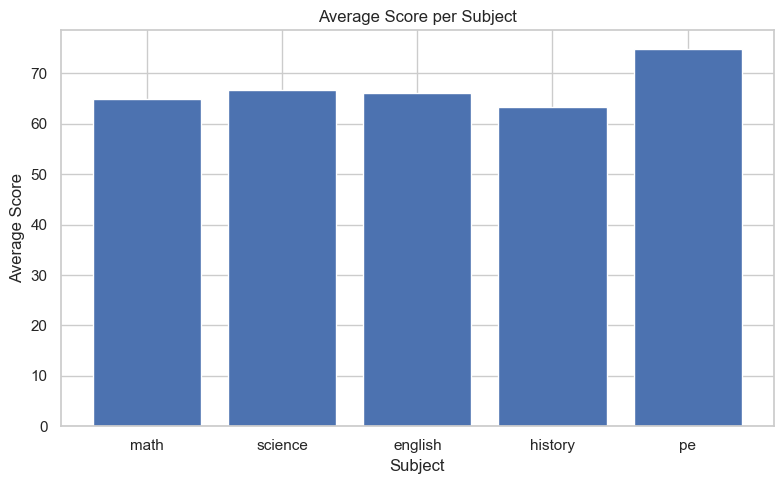

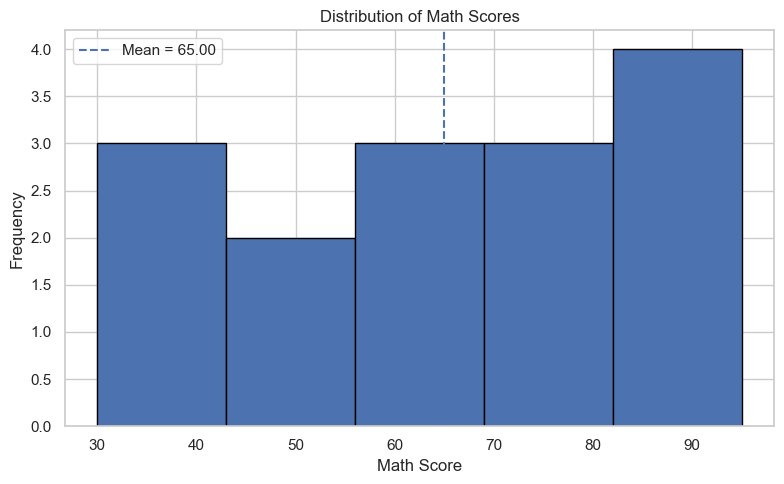

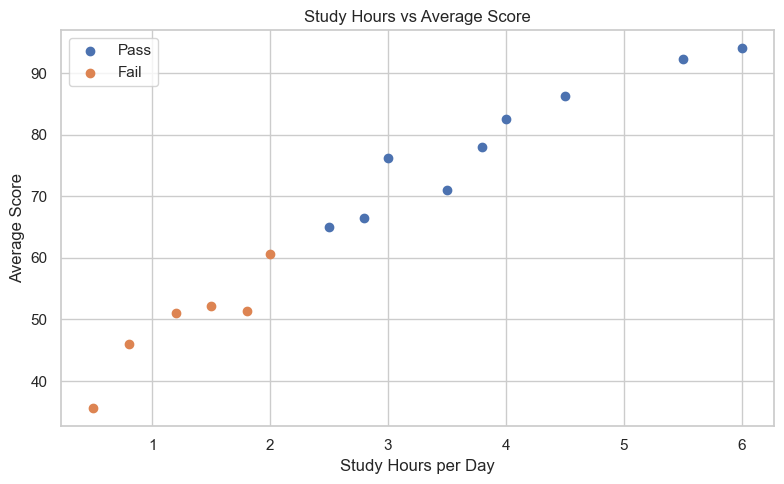

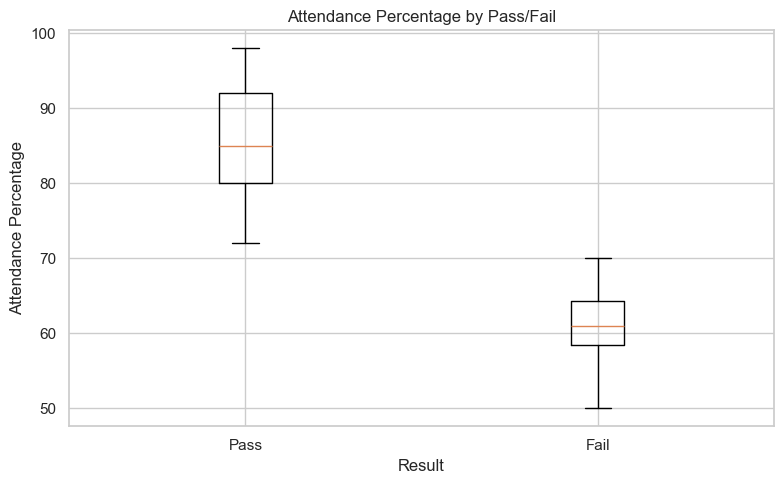

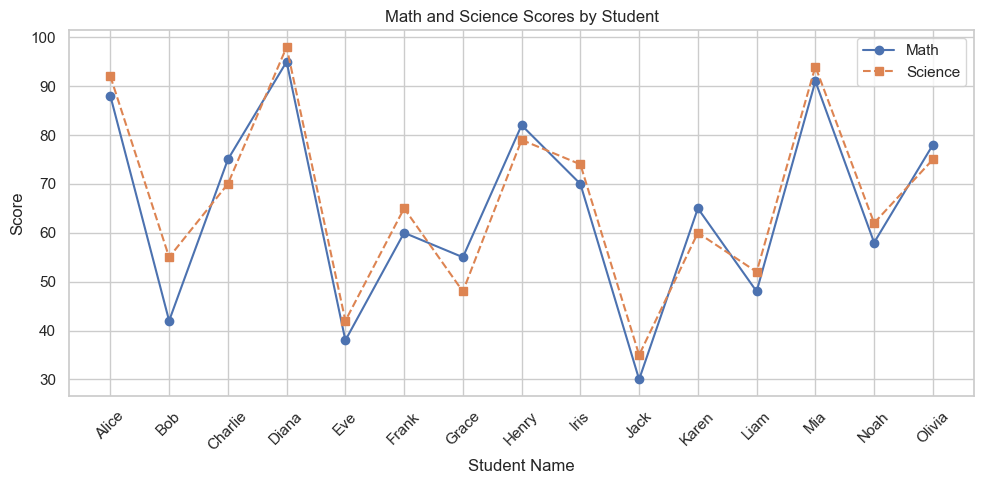

In [8]:
# ----------------------------
# Task 2 - Data Visualization with Matplotlib
# ----------------------------
print("\nTASK 2 - DATA VISUALIZATION WITH MATPLOTLIB")
print("-" * 60)

df['avg_score'] = df[subject_cols].mean(axis=1)

    # Plot 1 - Bar chart
subject_means = df[subject_cols].mean()
plt.figure(figsize=(8, 5))
plt.bar(subject_means.index, subject_means.values)
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("plot1_bar.png")
plt.show()

    # Plot 2 - Histogram
math_mean = df['math'].mean()
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, edgecolor='black')
plt.axvline(math_mean, linestyle='--', label=f"Mean = {math_mean:.2f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_histogram.png")
plt.show()

    # Plot 3 - Scatter plot
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.figure(figsize=(8, 5))
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot3_scatter.png")
plt.show()

    # Plot 4 - Box plot
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])
plt.title("Attendance Percentage by Pass/Fail")
plt.xlabel("Result")
plt.ylabel("Attendance Percentage")
plt.tight_layout()
plt.savefig("plot4_boxplot.png")
plt.show()

    # Plot 5 - Line plot
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science')
plt.title("Math and Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()


TASK 3 - DATA VISUALIZATION WITH SEABORN
------------------------------------------------------------


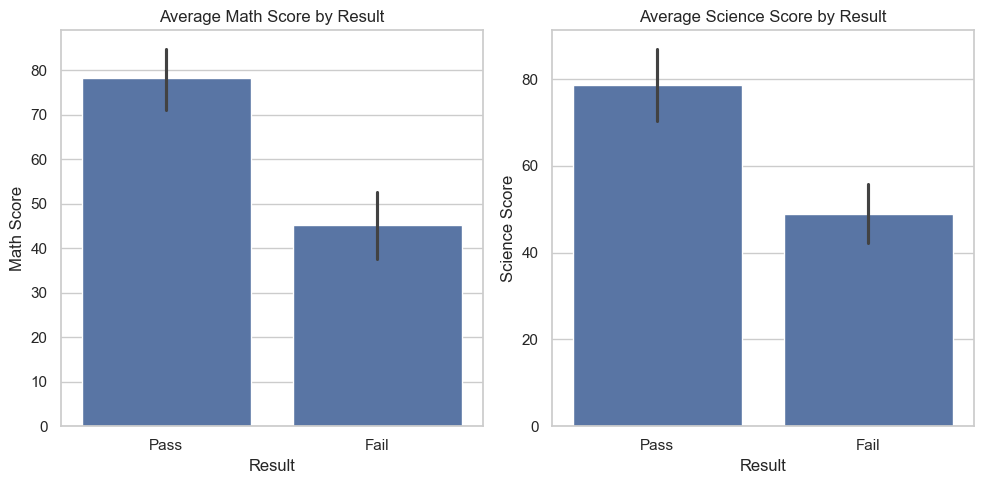

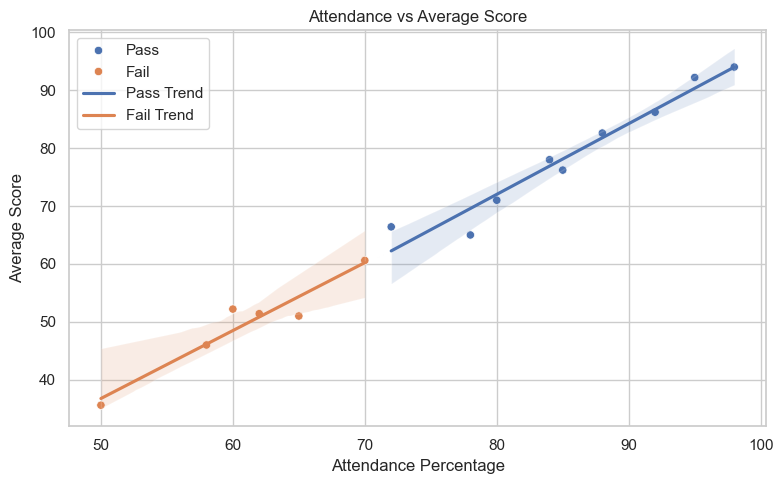

In [6]:
 # ----------------------------
    # Task 3 - Data Visualization with Seaborn
    # ----------------------------
print("\nTASK 3 - DATA VISUALIZATION WITH SEABORN")
print("-" * 60)

    # Seaborn felt quicker for statistical plots because the charts looked polished with less code.
    # Matplotlib gave more manual control over each element, but it required more setup for labels,
    # legends, and formatting details compared with Seaborn.

df['passed_label'] = df['passed'].map({1: 'Pass', 0: 'Fail'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
sns.barplot(data=df, x='passed_label', y='math', ax=ax1)
ax1.set_title("Average Math Score by Result")
ax1.set_xlabel("Result")
ax1.set_ylabel("Math Score")

sns.barplot(data=df, x='passed_label', y='science', ax=ax2)
ax2.set_title("Average Science Score by Result")
ax2.set_xlabel("Result")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_barplots.png")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed_label')
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', scatter=False, label='Pass Trend')
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score', scatter=False, label='Fail Trend')
plt.title("Attendance vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()



TASK 4 - MACHINE LEARNING WITH SCIKIT-LEARN
------------------------------------------------------------

Training accuracy: 1.00
Test accuracy: 1.00

Test set predictions:
Jack: Actual = Fail, Predicted = Fail -> ✅ correct
Liam: Actual = Fail, Predicted = Fail -> ✅ correct
Alice: Actual = Pass, Predicted = Pass -> ✅ correct

Feature coefficients sorted by absolute value:
english              0.8125
attendance_pct       0.5219
study_hours_per_day  0.4844
pe                   0.4750
math                 0.4379
science              0.3230
history              0.2629


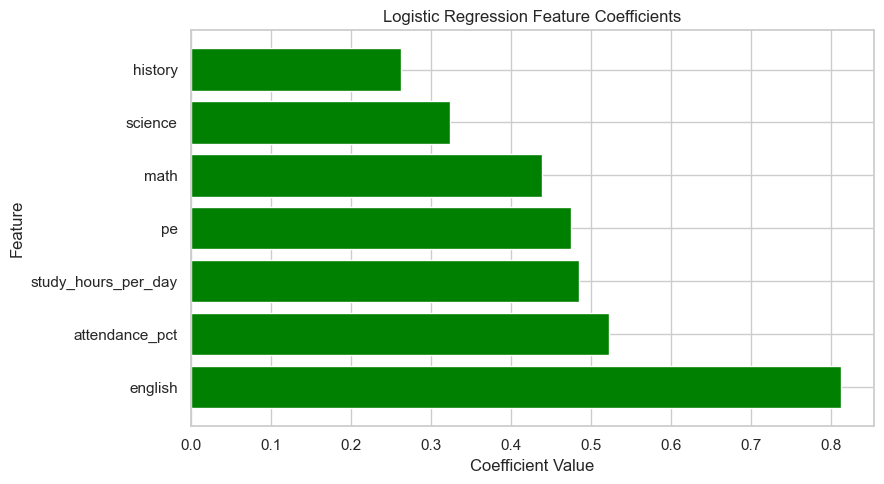


Bonus - New student prediction:
Predicted result: Pass
Probability [Fail, Pass]: [0.09203526 0.90796474]
TASK 1 - DATA EXPLORATION WITH PANDAS


In [12]:
# ----------------------------
# Task 4 - Machine Learning with scikit-learn
# ----------------------------
print("\nTASK 4 - MACHINE LEARNING WITH SCIKIT-LEARN")
print("-" * 60)

feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_accuracy = model.score(X_train_scaled, y_train)
print(f"\nTraining accuracy: {train_accuracy:.2f}")

y_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy:.2f}")

print("\nTest set predictions:")
test_names = df.loc[X_test.index, 'name']

for idx, name in zip(X_test.index, test_names):
    actual = df.loc[idx, 'passed']
    predicted = y_pred[list(X_test.index).index(idx)]
    status = "✅ correct" if actual == predicted else "❌ wrong"
    actual_label = "Pass" if actual == 1 else "Fail"
    predicted_label = "Pass" if predicted == 1 else "Fail"
    print(f"{name}: Actual = {actual_label}, Predicted = {predicted_label} -> {status}")

print("\nFeature coefficients sorted by absolute value:")
coefficients = model.coef_[0]
coefficient_pairs = list(zip(feature_cols, coefficients))
coefficient_pairs.sort(key=lambda item: abs(item[1]), reverse=True)

for feature, coef in coefficient_pairs:
    print(f"{feature:20} {coef:.4f}")

sorted_features = [item[0] for item in coefficient_pairs]
sorted_coefs = [item[1] for item in coefficient_pairs]
colors = ['green' if coef > 0 else 'red' for coef in sorted_coefs]

plt.figure(figsize=(9, 5))
plt.barh(sorted_features, sorted_coefs, color=colors)
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot8_feature_coefficients.png")
plt.show()

new_student = pd.DataFrame(
    [[75, 70, 68, 65, 80, 82, 3.2]],
    columns=feature_cols
)
new_student_scaled = scaler.transform(new_student)
new_prediction = model.predict(new_student_scaled)[0]
new_probability = model.predict_proba(new_student_scaled)[0]

predicted_result = "Pass" if new_prediction == 1 else "Fail"
print("\nBonus - New student prediction:")
print(f"Predicted result: {predicted_result}")
print(f"Probability [Fail, Pass]: {new_probability}")


if __name__ == "__main__":
    main()
